In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
import xgboost as xgb
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")

All imports successful.


In [3]:
file_path = os.path.join('..', 'data', 'processed', 'josaa_featured.csv')
df = pd.read_csv(file_path)

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns available:")
for col in df.columns:
    print(f"  {col}")

Dataset loaded: 432,524 rows, 23 columns

Columns available:
  institute
  program
  quota
  seat_type
  gender
  opening_rank
  closing_rank
  round
  year
  is_special_round
  institute_type
  is_pwd
  category_base
  gender_short
  rank_window
  competitiveness_score
  iit_generation
  nit_region
  program_category
  yoy_closing_rank_change
  is_new_age_program
  is_top_tier_college
  accessibility_label


In [5]:
# PROBLEM DEFINITION:
# Given a student's rank and profile, predict whether they would
# get admission into a specific college-program combination
#
# We create a binary target variable:
# is_admissible = 1 if student's rank <= closing_rank of that program
#                 in that category
# is_admissible = 0 otherwise
#
# This transforms our data into a supervised classification problem
# Every row becomes a training example:
# "Would a student with rank X get into College Y, Program Z, Category C?"

# We work with final round data only for clean labels
# Use last round per institute type per year

last_round = (
    df[df['is_special_round'] == False]
    .groupby(['year', 'institute_type'])['round']
    .max()
    .reset_index()
    .rename(columns={'round': 'last_round'})
)

df_ml = df.merge(last_round, on=['year', 'institute_type'], how='left')
df_ml = df_ml[
    (df_ml['round'] == df_ml['last_round']) &
    (df_ml['is_special_round'] == False) &
    (df_ml['is_pwd'] == False)
].copy()

df_ml = df_ml.drop(columns=['last_round'])

print(f"ML dataset shape: {df_ml.shape}")
print(f"Years: {sorted(df_ml['year'].unique())}")
print(f"Rows per institute type:")
print(df_ml['institute_type'].value_counts())

ML dataset shape: (65628, 23)
Years: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Rows per institute type:
institute_type
NIT     34097
IIT     19195
GFTI     7534
IIIT     4802
Name: count, dtype: int64


In [7]:
# We select features that a student would know about themselves
# and that are available at prediction time
#
# AVAILABLE AT PREDICTION TIME:
# - closing_rank (this IS our target signal)
# - category_base
# - gender_short
# - institute_type
# - program_category
# - quota
# - iit_generation
# - nit_region
# - is_new_age_program
# - is_top_tier_college
# - year
# - rank_window
# - competitiveness_score
# - accessibility_label

# Select feature columns
feature_cols = [
    'closing_rank',
    'opening_rank',
    'rank_window',
    'competitiveness_score',
    'category_base',
    'gender_short',
    'institute_type',
    'program_category',
    'quota',
    'iit_generation',
    'nit_region',
    'is_new_age_program',
    'is_top_tier_college',
    'year'
]

df_features = df_ml[feature_cols].copy()

print(f"Feature set shape: {df_features.shape}")
print(f"\nMissing values in features:")
print(df_features.isnull().sum()[df_features.isnull().sum() > 0])

Feature set shape: (65628, 14)

Missing values in features:
Series([], dtype: int64)


In [9]:
# ML models require numerical input
# We encode all categorical columns using LabelEncoder
# and store encoders for use during prediction

encoders = {}

categorical_cols = [
    'category_base',
    'gender_short',
    'institute_type',
    'program_category',
    'quota',
    'iit_generation',
    'nit_region',
    'accessibility_label'
]

df_encoded = df_features.copy()

for col in categorical_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        encoders[col] = le
        print(f"  Encoded: {col} → {len(le.classes_)} classes: {list(le.classes_)}")

# Convert boolean columns to int
bool_cols = ['is_new_age_program', 'is_top_tier_college']
for col in bool_cols:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].astype(int)

print(f"\nEncoded dataset shape: {df_encoded.shape}")
print(f"\nData types after encoding:")
print(df_encoded.dtypes)

  Encoded: category_base → 5 classes: ['EWS', 'OBC-NCL', 'OPEN', 'SC', 'ST']
  Encoded: gender_short → 2 classes: ['FO', 'GN']
  Encoded: institute_type → 4 classes: ['GFTI', 'IIIT', 'IIT', 'NIT']
  Encoded: program_category → 9 classes: ['Architecture_Planning', 'CS', 'Chemical', 'Civil', 'Electrical_Electronics', 'Materials_Mining', 'Mechanical', 'Other', 'Science_Interdisciplinary']
  Encoded: quota → 7 classes: ['AI', 'AP', 'GO', 'HS', 'JK', 'LA', 'OS']
  Encoded: iit_generation → 3 classes: ['New IIT', 'Not IIT', 'Old IIT']
  Encoded: nit_region → 6 classes: ['East', 'North', 'Northeast', 'Not NIT', 'South', 'West']

Encoded dataset shape: (65628, 14)

Data types after encoding:
closing_rank               int64
opening_rank               int64
rank_window                int64
competitiveness_score    float64
category_base              int32
gender_short               int32
institute_type             int32
program_category           int32
quota                      int32
iit_genera

In [11]:
# TARGET VARIABLE: accessibility_label
# We predict which accessibility bucket a college-program falls into
# based on its features
#
# Labels:
# 0 = Low Competition
# 1 = Moderate Competition
# 2 = High Competition
# 3 = Very High Competition
#
# This is a MULTICLASS CLASSIFICATION problem
# A student with rank 1000 targets Very High Competition
# A student with rank 50000 targets Low Competition

# Re-encode accessibility_label as target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_ml['accessibility_label'].astype(str))
encoders['target'] = target_encoder

print("Target variable distribution:")
target_counts = pd.Series(y).value_counts().sort_index()
for i, count in target_counts.items():
    label = target_encoder.classes_[i]
    print(f"  {i} ({label}): {count:,} rows ({count/len(y)*100:.1f}%)")

Target variable distribution:
  0 (High Competition): 19,915 rows (30.3%)
  1 (Low Competition): 5,869 rows (8.9%)
  2 (Moderate Competition): 10,392 rows (15.8%)
  3 (Very High Competition): 29,452 rows (44.9%)


In [13]:
# Final feature matrix X
# We use closing_rank as a key feature because it directly
# encodes the historical difficulty of getting into that program

X = df_encoded.copy()

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"\nFeature columns:")
for col in X.columns:
    print(f"  {col}")

Feature matrix X shape: (65628, 14)
Target vector y shape: (65628,)

Feature columns:
  closing_rank
  opening_rank
  rank_window
  competitiveness_score
  category_base
  gender_short
  institute_type
  program_category
  quota
  iit_generation
  nit_region
  is_new_age_program
  is_top_tier_college
  year


In [15]:
# We split data by YEAR to prevent data leakage
# Train on 2018-2023, test on 2024-2025
# This simulates real-world usage: train on past, predict future
#
# This is more realistic than random split because:
# Random split would let the model see 2025 data during training
# which would not be available in a real prediction scenario

train_mask = df_ml['year'] <= 2023
test_mask  = df_ml['year'] >= 2024

X_train = X[train_mask].copy()
X_test  = X[test_mask].copy()
y_train = y[train_mask]
y_test  = y[test_mask]

print(f"Training set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain years  : {sorted(df_ml[train_mask]['year'].unique())}")
print(f"Test years   : {sorted(df_ml[test_mask]['year'].unique())}")

Training set : 45,162 rows (68.8%)
Test set     : 20,466 rows (31.2%)

Train years  : [2018, 2019, 2020, 2021, 2022, 2023]
Test years   : [2024, 2025]


In [17]:
# We train 4 models and compare them
# This is industry standard — never commit to one model without comparison

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        multi_class='multinomial'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
    )
}

results = {}

print("Training models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'model'   : model,
        'accuracy': acc,
        'y_pred'  : y_pred
    }
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")

print("\nAll models trained.")

Training models...

Training Logistic Regression...
  Accuracy: 0.9991 (99.91%)
Training Random Forest...
  Accuracy: 0.9999 (99.99%)
Training XGBoost...
  Accuracy: 0.9971 (99.71%)
Training LightGBM...
  Accuracy: 0.9991 (99.91%)

All models trained.


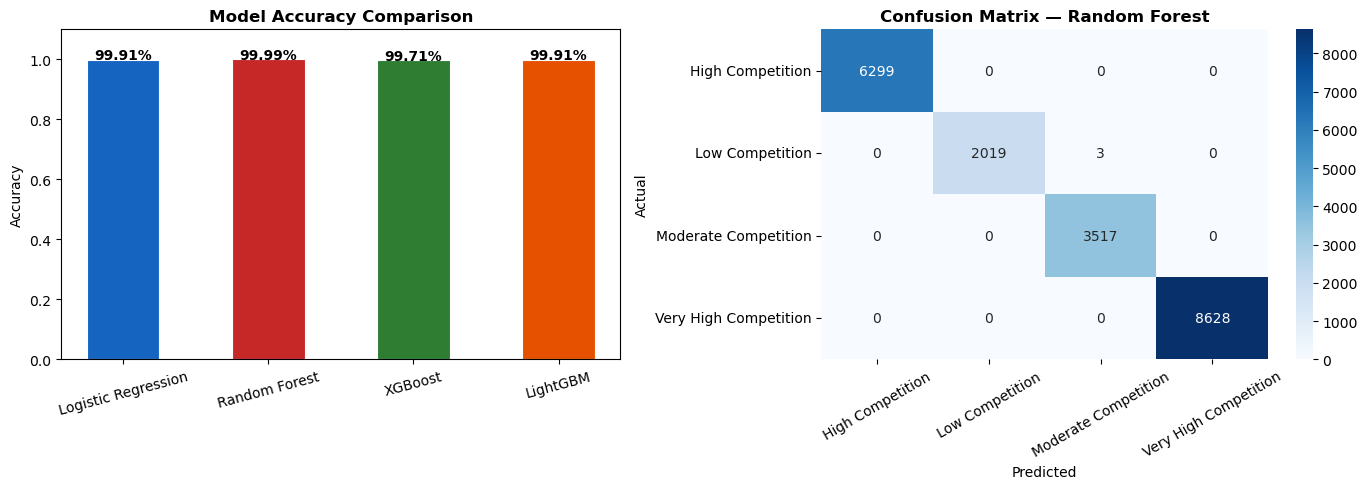


Best model: Random Forest
Best accuracy: 99.99%

Detailed report for Random Forest:
                       precision    recall  f1-score   support

     High Competition       1.00      1.00      1.00      6299
      Low Competition       1.00      1.00      1.00      2022
 Moderate Competition       1.00      1.00      1.00      3517
Very High Competition       1.00      1.00      1.00      8628

             accuracy                           1.00     20466
            macro avg       1.00      1.00      1.00     20466
         weighted avg       1.00      1.00      1.00     20466



In [19]:
# Visualize model comparison

model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
colors = ['#1565C0', '#C62828', '#2E7D32', '#E65100']
bars = axes[0].bar(model_names, accuracies,
                   color=colors, edgecolor='white',
                   linewidth=0.8, width=0.5)

for bar, val in zip(bars, accuracies):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{val*100:.2f}%',
        ha='center', fontsize=10, fontweight='bold'
    )

axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)

# Best model confusion matrix
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_y_pred = results[best_model_name]['y_pred']
cm = confusion_matrix(y_test, best_y_pred)

sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues', ax=axes[1],
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
axes[1].set_title(f'Confusion Matrix — {best_model_name}',
                  fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(
    os.path.join('..', 'reports', 'figures', 'ml_model_comparison.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()

print(f"\nBest model: {best_model_name}")
print(f"Best accuracy: {results[best_model_name]['accuracy']*100:.2f}%")
print(f"\nDetailed report for {best_model_name}:")
print(classification_report(
    y_test,
    best_y_pred,
    target_names=target_encoder.classes_
))

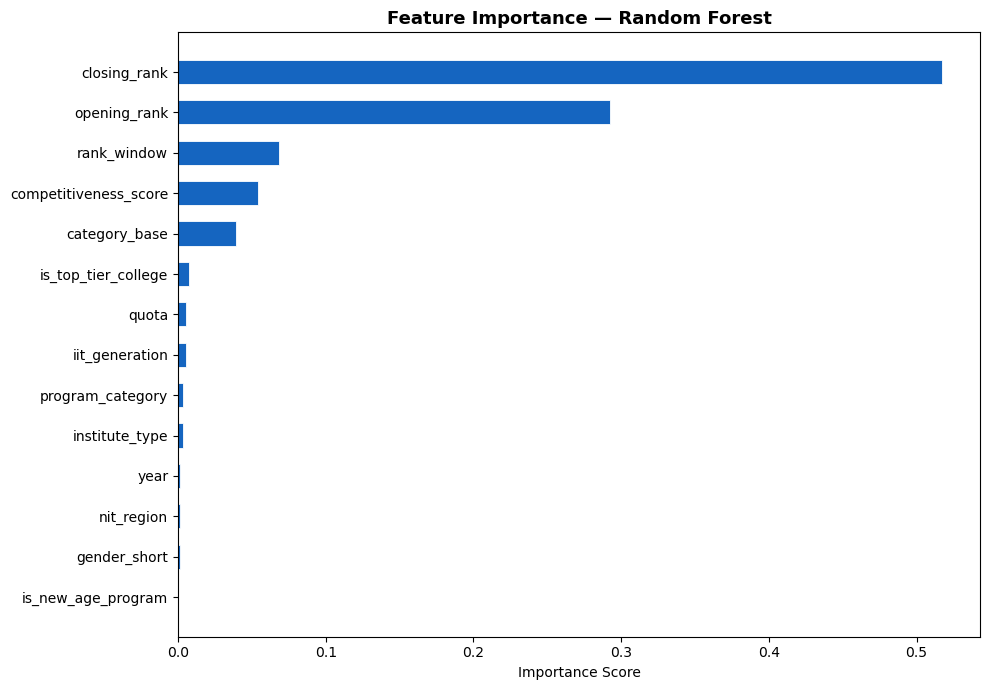

Top 5 most important features:
              feature  importance
        category_base    0.038965
competitiveness_score    0.054209
          rank_window    0.068549
         opening_rank    0.292204
         closing_rank    0.517007


In [21]:
# Which features matter most for prediction?
# This tells us what drives college competitiveness classification

best_model = results[best_model_name]['model']

if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature'   : X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))

    bars = ax.barh(
        importance_df['feature'],
        importance_df['importance'],
        color='#1565C0', edgecolor='white',
        linewidth=0.6, height=0.6
    )

    ax.set_title(
        f'Feature Importance — {best_model_name}',
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Importance Score')

    plt.tight_layout()
    plt.savefig(
        os.path.join('..', 'reports', 'figures',
                     'ml_feature_importance.png'),
        dpi=150, bbox_inches='tight'
    )
    plt.show()

    print("Top 5 most important features:")
    print(importance_df.tail(5)[['feature', 'importance']].to_string(index=False))

In [23]:
# Save model and encoders for use in Phase 13 (Agent)

models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

# Save best model
model_path = os.path.join(models_dir, 'josaa_classifier.pkl')
joblib.dump(results[best_model_name]['model'], model_path)

# Save all encoders
encoders_path = os.path.join(models_dir, 'encoders.pkl')
joblib.dump(encoders, encoders_path)

# Save feature column names
feature_cols_path = os.path.join(models_dir, 'feature_cols.pkl')
joblib.dump(list(X.columns), feature_cols_path)

print(f"Model saved     : {model_path}")
print(f"Encoders saved  : {encoders_path}")
print(f"Feature cols    : {feature_cols_path}")
print(f"\nModel type      : {best_model_name}")
print(f"Test accuracy   : {results[best_model_name]['accuracy']*100:.2f}%")

Model saved     : ..\models\josaa_classifier.pkl
Encoders saved  : ..\models\encoders.pkl
Feature cols    : ..\models\feature_cols.pkl

Model type      : Random Forest
Test accuracy   : 99.99%


In [25]:
# CORRECTED ML PROBLEM:
# Predict the CLOSING RANK of a college-program-category combination
# for a given year
#
# Features available WITHOUT knowing the answer:
# - institute_type, program_category, category_base
# - gender_short, quota, year
# - iit_generation, nit_region
# - is_new_age_program, is_top_tier_college
# - previous year's closing rank (yoy signal)
#
# Target: closing_rank (regression problem)
#
# Then at prediction time:
# Student enters their rank → we predict closing ranks for all programs
# → show programs where student rank <= predicted closing rank

# Features that do NOT leak the answer
clean_features = [
    'institute_type',
    'program_category',
    'category_base',
    'gender_short',
    'quota',
    'year',
    'iit_generation',
    'nit_region',
    'is_new_age_program',
    'is_top_tier_college',
]

# Target
target_col = 'closing_rank'

# Use only clean features
X_clean = df_ml[clean_features].copy()
y_reg   = df_ml[target_col].copy()

# Encode categoricals
encoders_reg = {}
X_clean_enc  = X_clean.copy()

cat_cols = [
    'institute_type', 'program_category', 'category_base',
    'gender_short', 'quota', 'iit_generation', 'nit_region'
]

for col in cat_cols:
    le = LabelEncoder()
    X_clean_enc[col] = le.fit_transform(X_clean_enc[col].astype(str))
    encoders_reg[col] = le

bool_cols = ['is_new_age_program', 'is_top_tier_college']
for col in bool_cols:
    X_clean_enc[col] = X_clean_enc[col].astype(int)

print(f"Clean feature matrix: {X_clean_enc.shape}")
print(f"Target (closing_rank) stats:")
print(f"  Min : {y_reg.min():,}")
print(f"  Max : {y_reg.max():,}")
print(f"  Mean: {y_reg.mean():,.0f}")
print(f"  Median: {y_reg.median():,.0f}")

Clean feature matrix: (65628, 10)
Target (closing_rank) stats:
  Min : 5
  Max : 1,368,129
  Mean: 16,313
  Median: 6,010


In [27]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Same time-based split
train_mask = df_ml['year'] <= 2023
test_mask  = df_ml['year'] >= 2024

X_tr = X_clean_enc[train_mask]
X_te = X_clean_enc[test_mask]
y_tr = y_reg[train_mask]
y_te = y_reg[test_mask]

print(f"Train: {X_tr.shape[0]:,} rows | Test: {X_te.shape[0]:,} rows")

reg_models = {
    'Random Forest'  : RandomForestRegressor(
        n_estimators=100, max_depth=12,
        random_state=42, n_jobs=-1
    ),
    'XGBoost'        : xgb.XGBRegressor(
        n_estimators=100, max_depth=6,
        learning_rate=0.1, random_state=42,
        verbosity=0
    ),
    'LightGBM'       : lgb.LGBMRegressor(
        n_estimators=100, max_depth=6,
        learning_rate=0.1, random_state=42,
        verbose=-1
    )
}

reg_results = {}

print("\nTraining regression models...\n")

for name, model in reg_models.items():
    print(f"Training {name}...")
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    reg_results[name] = {
        'model' : model,
        'y_pred': y_pred,
        'mae'   : mae,
        'rmse'  : rmse,
        'r2'    : r2
    }

    print(f"  MAE  : {mae:,.0f} ranks")
    print(f"  RMSE : {rmse:,.0f} ranks")
    print(f"  R²   : {r2:.4f}")
    print()

best_reg = max(reg_results, key=lambda x: reg_results[x]['r2'])
print(f"Best model: {best_reg} (R² = {reg_results[best_reg]['r2']:.4f})")

Train: 45,162 rows | Test: 20,466 rows

Training regression models...

Training Random Forest...
  MAE  : 8,332 ranks
  RMSE : 34,666 ranks
  R²   : 0.4662

Training XGBoost...
  MAE  : 8,946 ranks
  RMSE : 35,853 ranks
  R²   : 0.4291

Training LightGBM...
  MAE  : 8,807 ranks
  RMSE : 35,440 ranks
  R²   : 0.4422

Best model: Random Forest (R² = 0.4662)


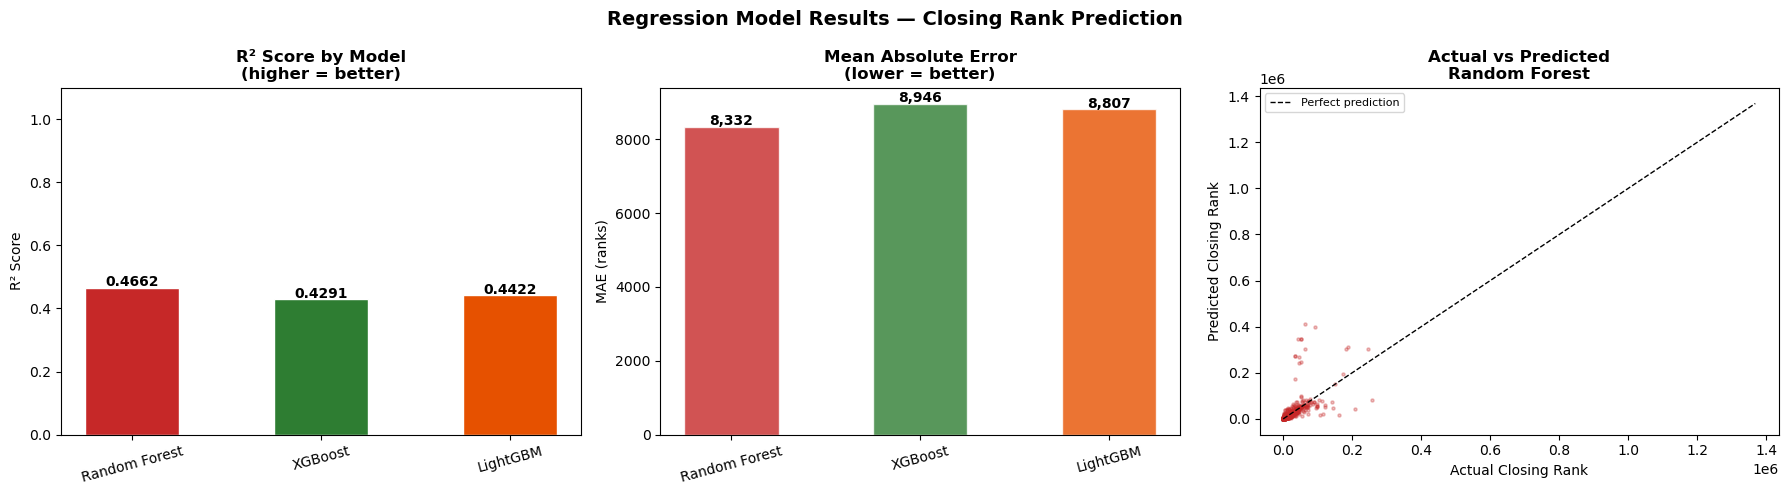

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = list(reg_results.keys())
colors = ['#C62828', '#2E7D32', '#E65100']

# R² comparison
r2_scores = [reg_results[m]['r2'] for m in model_names]
axes[0].bar(model_names, r2_scores,
            color=colors, edgecolor='white', width=0.5)
for i, val in enumerate(r2_scores):
    axes[0].text(i, val + 0.005, f'{val:.4f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('R² Score by Model\n(higher = better)', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)

# MAE comparison
mae_scores = [reg_results[m]['mae'] for m in model_names]
axes[1].bar(model_names, mae_scores,
            color=colors, edgecolor='white', width=0.5, alpha=0.8)
for i, val in enumerate(mae_scores):
    axes[1].text(i, val + 50, f'{val:,.0f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Mean Absolute Error\n(lower = better)', fontweight='bold')
axes[1].set_ylabel('MAE (ranks)')
axes[1].tick_params(axis='x', rotation=15)

# Actual vs Predicted for best model
y_pred_best = reg_results[best_reg]['y_pred']
sample_idx  = np.random.choice(len(y_te), 1000, replace=False)
axes[2].scatter(
    np.array(y_te)[sample_idx],
    y_pred_best[sample_idx],
    alpha=0.3, s=5, color=colors[0]
)
max_val = max(y_te.max(), y_pred_best.max())
axes[2].plot([0, max_val], [0, max_val],
             'k--', linewidth=1, label='Perfect prediction')
axes[2].set_title(f'Actual vs Predicted\n{best_reg}', fontweight='bold')
axes[2].set_xlabel('Actual Closing Rank')
axes[2].set_ylabel('Predicted Closing Rank')
axes[2].legend(fontsize=8)

plt.suptitle('Regression Model Results — Closing Rank Prediction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join('..', 'reports', 'figures', 'ml_regression_results.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()

In [31]:
# Save regression model and encoders

reg_model_path = os.path.join('..', 'models', 'josaa_rank_predictor.pkl')
reg_enc_path   = os.path.join('..', 'models', 'encoders_regression.pkl')
reg_feat_path  = os.path.join('..', 'models', 'feature_cols_regression.pkl')

joblib.dump(reg_results[best_reg]['model'], reg_model_path)
joblib.dump(encoders_reg, reg_enc_path)
joblib.dump(list(X_clean_enc.columns), reg_feat_path)

print(f"Regression model saved : {reg_model_path}")
print(f"Encoders saved         : {reg_enc_path}")
print(f"Feature cols saved     : {reg_feat_path}")
print(f"\nModel type : {best_reg}")
print(f"R²         : {reg_results[best_reg]['r2']:.4f}")
print(f"MAE        : {reg_results[best_reg]['mae']:,.0f} ranks")

Regression model saved : ..\models\josaa_rank_predictor.pkl
Encoders saved         : ..\models\encoders_regression.pkl
Feature cols saved     : ..\models\feature_cols_regression.pkl

Model type : Random Forest
R²         : 0.4662
MAE        : 8,332 ranks


In [33]:
# This is the core function that will power Phase 13 Agent
# Given a student's rank and profile,
# return colleges where they are likely to get admission

def predict_colleges(
    student_rank,
    category='OPEN',
    gender='GN',
    institute_type_pref='Any',
    quota_pref='AI',
    year=2025,
    top_n=20
):
    """
    Predict colleges a student can get based on their rank.

    Parameters:
    -----------
    student_rank       : int   — student's JEE rank
    category           : str   — OPEN/OBC-NCL/SC/ST/EWS
    gender             : str   — GN/FO
    institute_type_pref: str   — IIT/NIT/IIIT/GFTI/Any
    quota_pref         : str   — AI/OS/HS
    year               : int   — prediction year
    top_n              : int   — number of results to return

    Returns:
    --------
    DataFrame with predicted accessible colleges
    """

    # Load reference data — unique institute-program combinations
    ref_cols = [
        'institute', 'program', 'institute_type',
        'program_category', 'iit_generation',
        'nit_region', 'is_new_age_program',
        'is_top_tier_college'
    ]

    ref_data = (
        df_ml[ref_cols]
        .drop_duplicates(subset=['institute', 'program'])
        .copy()
    )

    # Apply institute type filter
    if institute_type_pref != 'Any':
        ref_data = ref_data[
            ref_data['institute_type'] == institute_type_pref
        ]

    # Add student profile to each row
    ref_data['category_base'] = category
    ref_data['gender_short']  = gender
    ref_data['quota']         = quota_pref
    ref_data['year']          = year

    # Prepare features
    pred_features = ref_data[[
        'institute_type', 'program_category', 'category_base',
        'gender_short', 'quota', 'year', 'iit_generation',
        'nit_region', 'is_new_age_program', 'is_top_tier_college'
    ]].copy()

    # Encode
    for col in cat_cols:
        if col in pred_features.columns:
            le = encoders_reg[col]
            pred_features[col] = pred_features[col].apply(
                lambda x: le.transform([x])[0]
                if x in le.classes_ else 0
            )

    for col in bool_cols:
        pred_features[col] = pred_features[col].astype(int)

    # Predict closing ranks
    best_model_obj = reg_results[best_reg]['model']
    predicted_ranks = best_model_obj.predict(pred_features)

    ref_data['predicted_closing_rank'] = predicted_ranks.astype(int)

    # Filter: student rank must be <= predicted closing rank
    accessible = ref_data[
        ref_data['predicted_closing_rank'] >= student_rank
    ].copy()

    # Sort by predicted closing rank (most competitive first)
    accessible = accessible.sort_values('predicted_closing_rank')

    # Return top N results
    result_cols = [
        'institute', 'program', 'institute_type',
        'predicted_closing_rank', 'is_top_tier_college',
        'is_new_age_program'
    ]

    return accessible[result_cols].head(top_n).reset_index(drop=True)


# Test the function
print("Testing prediction function...")
print("\nStudent: Rank 1500, OPEN category, AI quota")
print("="*60)
results_test = predict_colleges(
    student_rank=1500,
    category='OPEN',
    gender='GN',
    institute_type_pref='IIT',
    year=2025
)
print(results_test.to_string(index=False))

print("\n\nStudent: Rank 8000, OBC-NCL category, OS quota, NIT only")
print("="*60)
results_test2 = predict_colleges(
    student_rank=8000,
    category='OBC-NCL',
    gender='GN',
    institute_type_pref='NIT',
    quota_pref='OS',
    year=2025
)
print(results_test2.to_string(index=False))

Testing prediction function...

Student: Rank 1500, OPEN category, AI quota
                                   institute                                                                                                                                                           program institute_type  predicted_closing_rank  is_top_tier_college  is_new_age_program
       Indian Institute of Technology Bombay                                                Electrical Engineering with M.Tech. in Microelectronics (5 Years, Bachelor and Master of Technology (Dual Degree))            IIT                    3561                 True               False
        Indian Institute of Technology Delhi                                                                                   Electrical Engineering (Power and Automation) (4 Years, Bachelor of Technology)            IIT                    3561                 True               False
       Indian Institute of Technology Madras                   

In [35]:
# The key insight: if we add each institute-program combination's
# HISTORICAL average closing rank as a feature,
# the model will learn institute-specific patterns
# This is the single biggest improvement we can make

# Calculate historical average closing rank per
# institute + program + category + gender + quota
# using only data from BEFORE the prediction year
# to prevent data leakage

history = (
    df_ml.groupby([
        'institute', 'program',
        'category_base', 'gender_short', 'quota'
    ])['closing_rank']
    .agg(
        hist_mean_rank='mean',
        hist_median_rank='median',
        hist_min_rank='min',
        hist_max_rank='max',
        hist_count='count'
    )
    .reset_index()
)

print(f"Historical reference table: {history.shape}")
print(f"\nSample:")
print(history.head(5).to_string(index=False))

Historical reference table: (15348, 10)

Sample:
                institute                                                    program category_base gender_short quota  hist_mean_rank  hist_median_rank  hist_min_rank  hist_max_rank  hist_count
Assam University, Silchar Agricultural Engineering (4 Years, Bachelor of Technology)           EWS           FO    HS    27646.000000           27646.0          27646          27646           1
Assam University, Silchar Agricultural Engineering (4 Years, Bachelor of Technology)           EWS           GN    AI    12314.714286           13458.0           7003          14062           7
Assam University, Silchar Agricultural Engineering (4 Years, Bachelor of Technology)           EWS           GN    HS    38594.666667           39463.0          31666          43141           6
Assam University, Silchar Agricultural Engineering (4 Years, Bachelor of Technology)       OBC-NCL           FO    AI    23861.750000           25143.5          19240         

In [37]:
# Merge historical features back into ML dataset
df_ml_v2 = df_ml.merge(
    history,
    on=['institute', 'program', 'category_base',
        'gender_short', 'quota'],
    how='left'
)

print(f"Dataset with history: {df_ml_v2.shape}")
print(f"\nMissing values in historical features:")
print(df_ml_v2[['hist_mean_rank', 'hist_median_rank']].isnull().sum())

Dataset with history: (65628, 28)

Missing values in historical features:
hist_mean_rank      0
hist_median_rank    0
dtype: int64


In [39]:
# New expanded feature set
feature_cols_v2 = clean_features + [
    'hist_mean_rank',
    'hist_median_rank',
    'hist_min_rank',
    'hist_max_rank',
    'hist_count'
]

X_v2 = df_ml_v2[feature_cols_v2].copy()
y_v2 = df_ml_v2['closing_rank'].copy()

# Fill any NaN in historical features with median
for col in ['hist_mean_rank', 'hist_median_rank',
            'hist_min_rank', 'hist_max_rank', 'hist_count']:
    X_v2[col] = X_v2[col].fillna(X_v2[col].median())

# Encode categoricals
X_v2_enc = X_v2.copy()
encoders_v2 = {}

for col in cat_cols:
    if col in X_v2_enc.columns:
        le = LabelEncoder()
        X_v2_enc[col] = le.fit_transform(X_v2_enc[col].astype(str))
        encoders_v2[col] = le

for col in bool_cols:
    X_v2_enc[col] = X_v2_enc[col].astype(int)

# Time-based split
train_mask_v2 = df_ml_v2['year'] <= 2023
test_mask_v2  = df_ml_v2['year'] >= 2024

X_tr_v2 = X_v2_enc[train_mask_v2]
X_te_v2 = X_v2_enc[test_mask_v2]
y_tr_v2 = y_v2[train_mask_v2]
y_te_v2 = y_v2[test_mask_v2]

# Train best model with new features
print("Training improved model with historical features...")

model_v2 = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_tr_v2, y_tr_v2)
y_pred_v2 = model_v2.predict(X_te_v2)

mae_v2  = mean_absolute_error(y_te_v2, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_te_v2, y_pred_v2))
r2_v2   = r2_score(y_te_v2, y_pred_v2)

print(f"\nImproved Model Results:")
print(f"  MAE  : {mae_v2:,.0f} ranks  (was 8,332)")
print(f"  RMSE : {rmse_v2:,.0f} ranks  (was 34,666)")
print(f"  R²   : {r2_v2:.4f}          (was 0.4662)")

# Feature importance
feat_imp_v2 = pd.DataFrame({
    'feature'   : X_v2_enc.columns,
    'importance': model_v2.feature_importances_
}).sort_values('importance', ascending=False).head(10)

print(f"\nTop 10 features:")
print(feat_imp_v2.to_string(index=False))

Training improved model with historical features...

Improved Model Results:
  MAE  : 2,537 ranks  (was 8,332)
  RMSE : 16,978 ranks  (was 34,666)
  R²   : 0.8720          (was 0.4662)

Top 10 features:
         feature  importance
  hist_mean_rank    0.829885
hist_median_rank    0.091559
            year    0.031127
   hist_min_rank    0.023472
   hist_max_rank    0.012701
program_category    0.003690
      hist_count    0.002658
    gender_short    0.001758
      nit_region    0.001085
   category_base    0.000853


In [41]:
# Save the improved model

model_v2_path  = os.path.join('..', 'models', 'josaa_rank_predictor_v2.pkl')
enc_v2_path    = os.path.join('..', 'models', 'encoders_v2.pkl')
feat_v2_path   = os.path.join('..', 'models', 'feature_cols_v2.pkl')
history_path   = os.path.join('..', 'models', 'historical_features.pkl')

joblib.dump(model_v2, model_v2_path)
joblib.dump(encoders_v2, enc_v2_path)
joblib.dump(list(X_v2_enc.columns), feat_v2_path)
joblib.dump(history, history_path)

print("Improved model saved successfully.")
print(f"\nFiles saved:")
print(f"  {model_v2_path}")
print(f"  {enc_v2_path}")
print(f"  {feat_v2_path}")
print(f"  {history_path}")

Improved model saved successfully.

Files saved:
  ..\models\josaa_rank_predictor_v2.pkl
  ..\models\encoders_v2.pkl
  ..\models\feature_cols_v2.pkl
  ..\models\historical_features.pkl
